## 📦 Step 0 — Install Libraries

In [ ]:
!pip install pandas scikit-learn xgboost imbalanced-learn matplotlib seaborn joblib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📥 Step 1 — Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection   import train_test_split, cross_val_score
from sklearn.preprocessing     import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model      import LogisticRegression
from sklearn.svm               import SVC
from sklearn.metrics           import (accuracy_score, classification_report,
                                        confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling    import SMOTE
from xgboost                   import XGBClassifier

print('All libraries imported!')

✅ All libraries imported!


##  Step 2 — Configuration 

In [4]:

DATA_PATH      =  r"C:\Users\hp\OneDrive\Desktop\ml_model_training\clean_numeric_dataset.parquet"
LABEL_COLUMN   = 'label'
TEST_SIZE      = 0.2
RANDOM_STATE   = 42
CORR_THRESHOLD = 0.9
TOP_K          = 30
MI_SUBSET      = 100000

print('✅ Config set!')

✅ Config set!


##  Step 3 — Data Loading + Duplicate Removal

In [5]:
df = pd.read_csv(r'C:\Users\hp\OneDrive\Desktop\ml_model_training\clean_numeric_dataset.parquet')

In [7]:
print("Final shape:", df.shape)

Final shape: (2093190, 70)


In [8]:
print(df['label'].value_counts())

label
Benign        1758888
DoS            193745
DDoS           128014
BruteForce       9150
PortScan         1956
Bot              1437
Name: count, dtype: int64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2093190 entries, 0 to 2093189
Data columns (total 70 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   protocol                  int64  
 1   flow_duration             float64
 2   total_fwd_packets         int64  
 3   total_backward_packets    int64  
 4   fwd_packets_length_total  int64  
 5   bwd_packets_length_total  float64
 6   fwd_packet_length_max     int64  
 7   fwd_packet_length_min     int64  
 8   fwd_packet_length_mean    float64
 9   fwd_packet_length_std     float64
 10  bwd_packet_length_max     int64  
 11  bwd_packet_length_min     int64  
 12  bwd_packet_length_mean    float64
 13  bwd_packet_length_std     float64
 14  flow_bytes/s              float64
 15  flow_packets/s            float64
 16  flow_iat_mean             float64
 17  flow_iat_std              float64
 18  flow_iat_max              int64  
 19  flow_iat_min              float64
 20  fwd_iat_total           

##  Step 4 — Correlation Matrix + Remove High-Corr Features

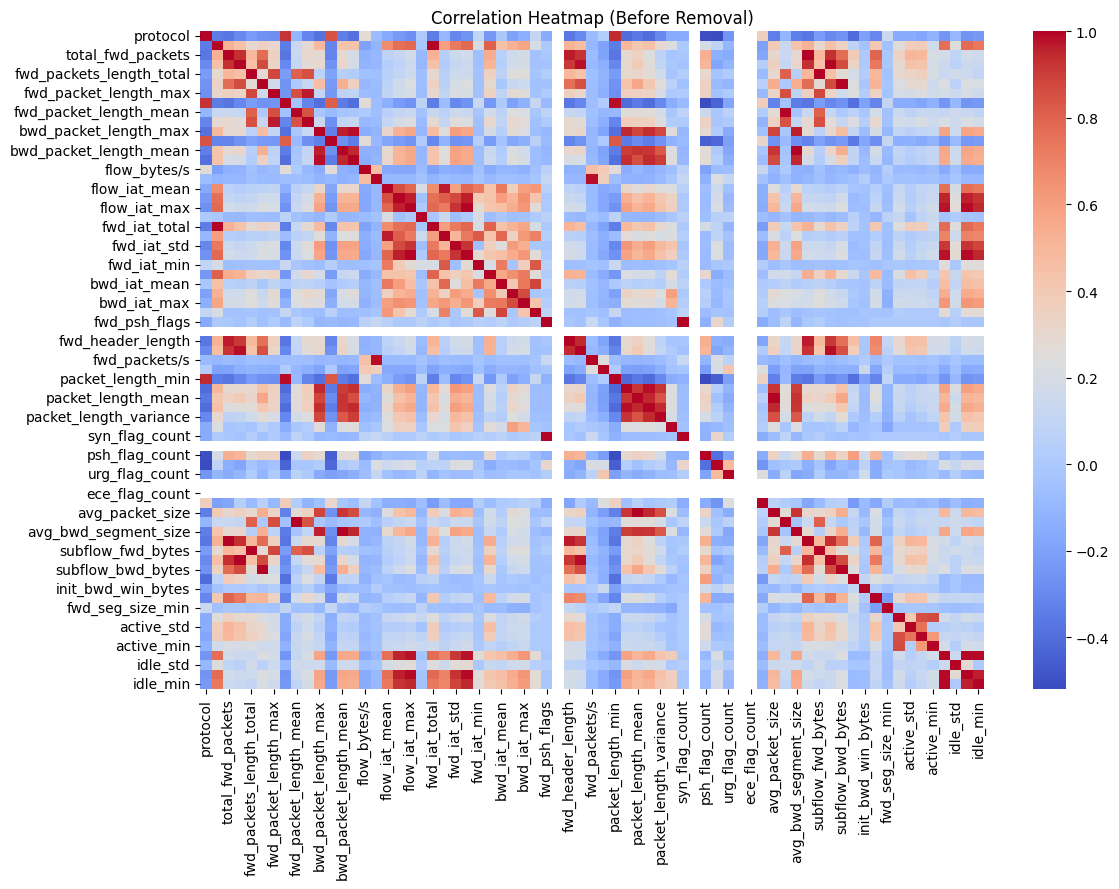

Dropped highly correlated features: ['total_backward_packets', 'fwd_packet_length_min', 'fwd_packet_length_std', 'bwd_packet_length_mean', 'bwd_packet_length_std', 'flow_iat_max', 'fwd_iat_total', 'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max', 'fwd_header_length', 'bwd_header_length', 'fwd_packets/s', 'packet_length_min', 'packet_length_max', 'packet_length_mean', 'packet_length_std', 'packet_length_variance', 'syn_flag_count', 'avg_packet_size', 'avg_fwd_segment_size', 'avg_bwd_segment_size', 'subflow_fwd_packets', 'subflow_fwd_bytes', 'subflow_bwd_packets', 'subflow_bwd_bytes', 'idle_mean', 'idle_max', 'idle_min']
Remaining features: 40 (+ label)


In [10]:
import seaborn as sns
import numpy as np

# Correlation matrix
corr_matrix = df.drop(columns=[LABEL_COLUMN]).corr()

# Plot heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap (Before Removal)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

# Remove features with correlation > 0.9
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column].abs() > CORR_THRESHOLD)]
df = df.drop(columns=to_drop)

print('Dropped highly correlated features:', to_drop)
print('Remaining features:', df.shape[1]-1, '(+ label)')

##  Step 5 — Mutual Information Feature Selection (Top 30)

In [11]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Features and target
X = df.drop(LABEL_COLUMN, axis=1)
y = df[LABEL_COLUMN]

# Use subset for speed
subset_size = MI_SUBSET
if len(df) > subset_size:
    X_small = X.sample(n=subset_size, random_state=RANDOM_STATE)
    y_small = y.loc[X_small.index]
else:
    X_small = X
    y_small = y

print(f'Fitting MI on {X_small.shape[0]:,} rows...')

# Fit MI selector on subset
mi_selector = SelectKBest(score_func=mutual_info_classif, k=TOP_K)
mi_selector.fit(X_small, y_small)

# Get top feature names
top_features = X.columns[mi_selector.get_support()].tolist()
print('Top 30 features by Mutual Information:\n', top_features)

# Apply top features on full dataset
df_top_features = df[top_features + [LABEL_COLUMN]]

# Save final dataset
df_top_features.to_csv('clean_numeric_top_features.csv', index=False)
print(' Final ML-ready dataset with top features saved!')
print('Shape:', df_top_features.shape)

Fitting MI on 100,000 rows...
Top 30 features by Mutual Information:
 ['protocol', 'flow_duration', 'total_fwd_packets', 'fwd_packets_length_total', 'bwd_packets_length_total', 'fwd_packet_length_max', 'fwd_packet_length_mean', 'bwd_packet_length_max', 'bwd_packet_length_min', 'flow_bytes/s', 'flow_packets/s', 'flow_iat_mean', 'flow_iat_std', 'flow_iat_min', 'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean', 'bwd_iat_std', 'bwd_iat_max', 'bwd_iat_min', 'bwd_packets/s', 'fin_flag_count', 'down/up_ratio', 'init_fwd_win_bytes', 'init_bwd_win_bytes', 'fwd_act_data_packets', 'fwd_seg_size_min', 'active_mean', 'active_max', 'active_min']
 Final ML-ready dataset with top features saved!
Shape: (2093190, 31)


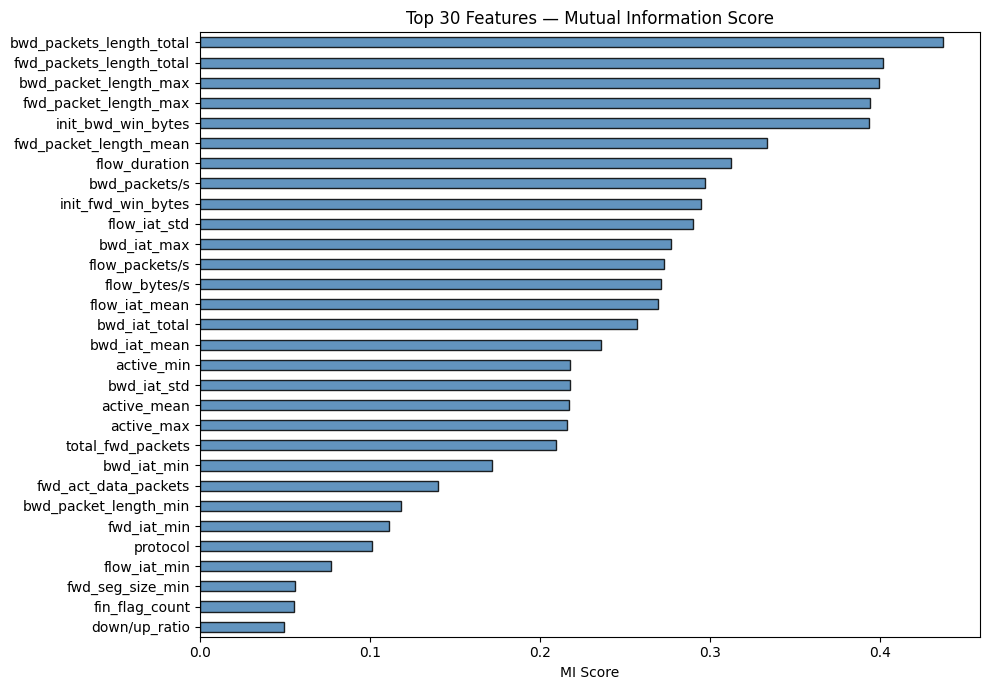

In [12]:
# MI Score Chart
mi_scores = mi_selector.scores_[mi_selector.get_support()]
mi_series = pd.Series(mi_scores, index=top_features).sort_values(ascending=False)
plt.figure(figsize=(10, 7))
mi_series.plot(kind='barh', color='steelblue', edgecolor='black', alpha=0.85)
plt.gca().invert_yaxis()
plt.title('Top 30 Features — Mutual Information Score')
plt.xlabel('MI Score')
plt.tight_layout()
plt.savefig('mutual_information.png', dpi=150)
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

In [14]:
y = df['label']

In [15]:
print(df['label'].value_counts())

label
0    1758888
4     193745
3     128014
2       9150
5       1956
1       1437
Name: count, dtype: int64


##  Step 6 — Train / Test Split (80/20 Stratified)

In [16]:
from sklearn.model_selection import train_test_split

X = df_top_features.drop(LABEL_COLUMN, axis=1)
y = df_top_features[LABEL_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
# ── Step 1: Training dataset ──
train_df = pd.concat([X_train, y_train], axis=1)
train_df.to_csv('train_dataset.csv', index=False)
print(" Training dataset saved as 'train_dataset.csv'")

# ── Step 2: Testing dataset WITH labels ──
test_with_label_df = pd.concat([X_test, y_test], axis=1)
test_with_label_df.to_csv('test_dataset_with_label.csv', index=False)
print(" Testing dataset with labels saved as 'test_dataset_with_label.csv'")

# ── Step 3: Testing dataset WITHOUT labels ──
test_without_label_df = X_test.copy()  # only features
test_without_label_df.to_csv('test_dataset_without_label.csv', index=False)
print("Testing dataset without labels saved as 'test_dataset_without_label.csv'")

Train shape: (1674552, 30)
Test shape: (418638, 30)
 Training dataset saved as 'train_dataset.csv'
 Testing dataset with labels saved as 'test_dataset_with_label.csv'
Testing dataset without labels saved as 'test_dataset_without_label.csv'


##  Step 7 — Standard Scaler

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, 'scaler.pkl')
print('X_train_scaled shape:', X_train_scaled.shape)
print('X_test_scaled shape :', X_test_scaled.shape)
print('Scaler saved!')

X_train_scaled shape: (1674552, 30)
X_test_scaled shape : (418638, 30)
✅ Scaler saved!


In [18]:
print(df['label'].value_counts())

label
0    1758888
4     193745
3     128014
2       9150
5       1956
1       1437
Name: count, dtype: int64


In [19]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\ny_train class distribution:")
print(pd.Series(y_train).value_counts())

X_train shape: (1674552, 30)
y_train shape: (1674552,)

y_train class distribution:
label
Benign        1407110
DoS            154996
DDoS           102411
BruteForce       7320
PortScan         1565
Bot              1150
Name: count, dtype: int64


In [ ]:
# from imblearn.over_sampling import SMOTE
# import pandas as pd

# # Majority class (Benign)
# class0_count = pd.Series(y_train).value_counts()['Benign']

# # String-based sampling strategy (IMPORTANT FIX )
# sampling_strategy = {
#     'DoS': int(class0_count * 0.20),
#     'DDoS': int(class0_count * 0.30),
#     'BruteForce': int(class0_count * 0.50),
#     'PortScan': int(class0_count * 0.60),
#     'Bot': int(class0_count * 0.70),
# }

# print('Before SMOTE:')
# print(pd.Series(y_train).value_counts())

# smote = SMOTE(
#     sampling_strategy=sampling_strategy,
#     random_state=RANDOM_STATE
# )

# X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# print('\nAfter SMOTE:')
# print(pd.Series(y_train_bal).value_counts())
# print('Balanced Train shape:', X_train_bal.shape)

Before SMOTE:
label
Benign        1407110
DoS            154996
DDoS           102411
BruteForce       7320
PortScan         1565
Bot              1150
Name: count, dtype: int64

After SMOTE:
label
Benign        1407110
Bot            984976
PortScan       844266
BruteForce     703555
DDoS           422133
DoS            281422
Name: count, dtype: int64
Balanced Train shape: (4643462, 30)


##  Step 8 — SMOTE (Class Imbalance Fix)

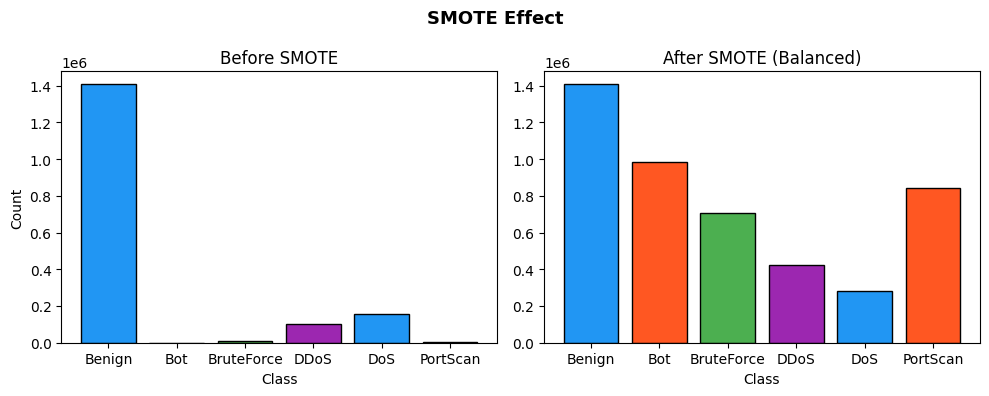

In [ ]:
# # SMOTE Before/After Chart
# fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# clr = ['#2196F3','#FF5722','#4CAF50','#9C27B0']
# u1, c1 = np.unique(y_train, return_counts=True)
# u2, c2 = np.unique(y_train_bal, return_counts=True)
# axes[0].bar([str(c) for c in u1], c1, color=clr[:len(u1)], edgecolor='black')
# axes[0].set_title('Before SMOTE'); axes[0].set_xlabel('Class'); axes[0].set_ylabel('Count')
# axes[1].bar([str(c) for c in u2], c2, color=clr[:len(u2)], edgecolor='black')
# axes[1].set_title('After SMOTE (Balanced)'); axes[1].set_xlabel('Class')
# fig.suptitle('SMOTE Effect', fontsize=13, fontweight='bold')
# plt.tight_layout()
# plt.savefig('smote_effect.png', dpi=150)
# plt.show()

##  Step 9 — Train 5 Models
> Random Forest | Logistic Regression | Gradient Boosting | XGBoost | SVM

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sample_size = 1000000   
# 1️ Split

# ── Sample from scaled training data ──
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_scaled,   # use scaled data
    y_train,
    train_size=sample_size,
    stratify=y_train,
    random_state=RANDOM_STATE
)

print("Sampled train shape:", X_train_sample.shape)
print("Sampled train class distribution:\n", pd.Series(y_train_sample).value_counts())


model_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced'
)
model_rf.fit(X_train_sample, y_train_sample)




# 5️ Predict
y_pred = model_rf.predict(X_test_scaled)

# 6️ Evaluate
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

Sampled train shape: (1000000, 30)
Sampled train class distribution:
 label
Benign        840290
DoS            92560
DDoS           61157
BruteForce      4371
PortScan         935
Bot              687
Name: count, dtype: int64
Accuracy: 0.9989155308404875
Classification Report:
               precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    351778
         Bot       0.71      0.72      0.72       287
  BruteForce       1.00      0.99      0.99      1830
        DDoS       1.00      1.00      1.00     25603
         DoS       1.00      1.00      1.00     38749
    PortScan       0.95      0.93      0.94       391

    accuracy                           1.00    418638
   macro avg       0.94      0.94      0.94    418638
weighted avg       1.00      1.00      1.00    418638

Confusion Matrix:
 [[351548     85      1      3    125     16]
 [    79    208      0      0      0      0]
 [    18      0   1812      0      0      0]
 [    13      0      0

###  Model 2 — Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# ── Step 1: Sample from SCALED training data ──
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_scaled,    
    y_train,
    train_size=100000,  
    stratify=y_train,
    random_state=RANDOM_STATE
)

print(f" Sample size : {X_train_sample.shape}")
print(f"   Test size  : {X_test_scaled.shape}")

print("\nSample class distribution:")
print(pd.Series(y_train_sample).value_counts())

# ── Step 2: Model ──
model_lr = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight=None,
    n_jobs=-1   
)

# ── Step 3: Train ──
model_lr.fit(X_train_sample, y_train_sample)
print('\n Model training completed!')

# ── Step 4: Predict on FULL test ──
y_pred_lr = model_lr.predict(X_test_scaled)

# ── Step 5: Evaluation ──
print('\nAccuracy:', accuracy_score(y_test, y_pred_lr))
print('\nClassification Report:\n', classification_report(y_test, y_pred_lr))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred_lr))

 Sample size : (100000, 30)
   Test size  : (418638, 30)

Sample class distribution:
label
Benign        84029
DoS            9256
DDoS           6116
BruteForce      437
PortScan         93
Bot              69
Name: count, dtype: int64

 Model training completed!

Accuracy: 0.9848723718343771

Classification Report:
               precision    recall  f1-score   support

      Benign       0.99      0.99      0.99    351778
         Bot       0.00      0.00      0.00       287
  BruteForce       0.79      0.75      0.77      1830
        DDoS       0.99      0.99      0.99     25603
         DoS       0.96      0.92      0.94     38749
    PortScan       1.00      0.12      0.21       391

    accuracy                           0.98    418638
   macro avg       0.79      0.63      0.65    418638
weighted avg       0.98      0.98      0.98    418638


Confusion Matrix:
 [[349750      0    311    334   1383      0]
 [   287      0      0      0      0      0]
 [   462      0   1368     

###  Model 3 — Gradient Boosting  

###  Model 4 — XGBoost

In [22]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ── Step 0: Encode labels ──
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)   # fit on train
y_test_enc  = le.transform(y_test)        # transform test

# ── Step 1: 100k stratified sample ──
_, X_train_sample, _, y_train_sample = train_test_split(
    X_train_scaled,
    y_train_enc,   #  encoded labels use karo
    test_size=100000,
    stratify=y_train_enc,
    random_state=RANDOM_STATE
)

print(f" Sample size : {X_train_sample.shape}")
print(f" Test size  : {X_test_scaled.shape}")

print("\nSample class distribution:")
print(pd.Series(y_train_sample).value_counts().sort_index())

# ── Step 2: Model ──
model_xgb = XGBClassifier(
    n_estimators=200,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    verbosity=0,
    n_jobs=-1
)

# ── Step 3: Train ──
model_xgb.fit(X_train_sample, y_train_sample)
print(' Model training completed!')

# ── Step 4: Predict ──
y_pred_xgb = model_xgb.predict(X_test_scaled)

# ── Step 5: Convert back to original labels (IMPORTANT) ──
y_pred_labels = le.inverse_transform(y_pred_xgb)
y_test_labels = le.inverse_transform(y_test_enc)

# ── Step 6: Results ──
print('\nAccuracy:', accuracy_score(y_test_labels, y_pred_labels))
print('\nClassification Report:\n', classification_report(y_test_labels, y_pred_labels))
print('\nConfusion Matrix:\n', confusion_matrix(y_test_labels, y_pred_labels))

 Sample size : (100000, 30)
 Test size  : (418638, 30)

Sample class distribution:
0    84029
1       69
2      437
3     6116
4     9256
5       93
Name: count, dtype: int64
 Model training completed!

Accuracy: 0.9986479965984932

Classification Report:
               precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    351778
         Bot       0.76      0.57      0.65       287
  BruteForce       0.99      0.98      0.99      1830
        DDoS       1.00      1.00      1.00     25603
         DoS       1.00      1.00      1.00     38749
    PortScan       0.97      0.88      0.93       391

    accuracy                           1.00    418638
   macro avg       0.95      0.91      0.93    418638
weighted avg       1.00      1.00      1.00    418638


Confusion Matrix:
 [[351526     52     11      8    173      8]
 [   122    165      0      0      0      0]
 [    29      0   1800      0      0      1]
 [    36      0      0  25562      5      0]


### Step 10 — Model Comparison Chart

  Model                    Accuracy
 🏆 Random Forest              99.89%
 Logistic Regression        98.49%
 XGBoost                    99.86%


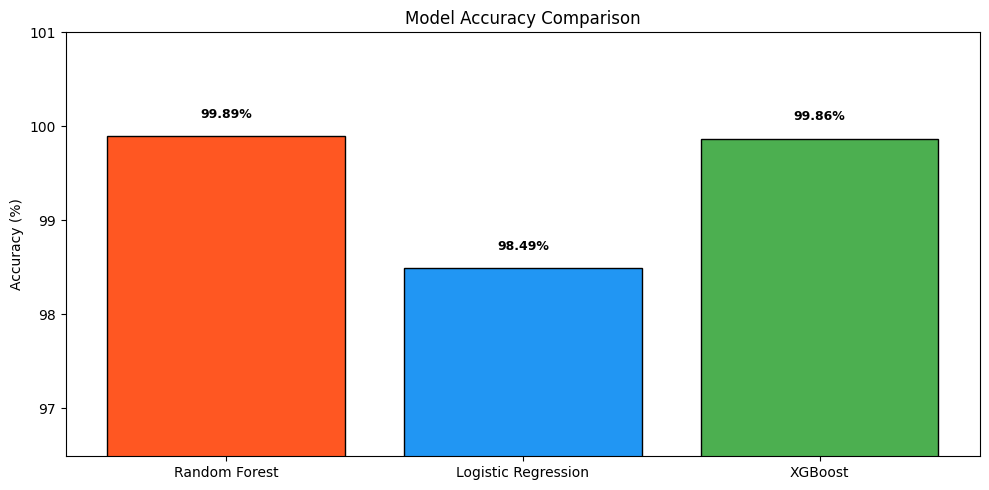

In [ ]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder

model_names  = ['Random Forest', 'Logistic Regression', 'XGBoost']
model_preds  = [y_pred , y_pred_lr, y_pred_xgb]

# Fix XGBoost predictions: convert numeric to original string labels
le = LabelEncoder()
le.fit(y_test)  # fit on original labels

fixed_preds = []
for pred, name in zip(model_preds, model_names):
    if name == 'XGBoost':
        # Convert numeric predictions to original string labels
        fixed_preds.append(le.inverse_transform(pred))
    else:
        fixed_preds.append(pred)

accuracies = [accuracy_score(y_test, p) for p in fixed_preds]

print('='*55)
print(f'  {"Model":<22} {"Accuracy":>10}')
print('='*55)

for name, acc in zip(model_names, accuracies):
    flag = ' 🏆' if acc == max(accuracies) else ''
    print(f'{flag} {name:<22} {acc*100:>9.2f}%')

print('='*55)

# Accuracy bar chart
colors = [
    '#FF5722', '#2196F3', '#4CAF50']

plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, [a*100 for a in accuracies], color=colors, edgecolor='black')

plt.ylim(min([a*100 for a in accuracies])-2, 101)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')

for bar_, acc in zip(bars, accuracies):
    plt.text(bar_.get_x()+bar_.get_width()/2, bar_.get_height()+0.2,
             f'{acc*100:.2f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

step 11 confusion matrixs

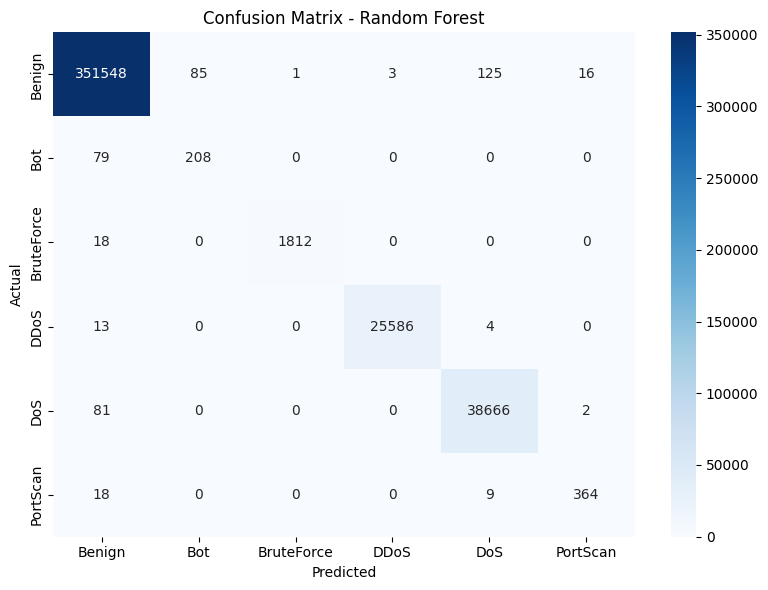

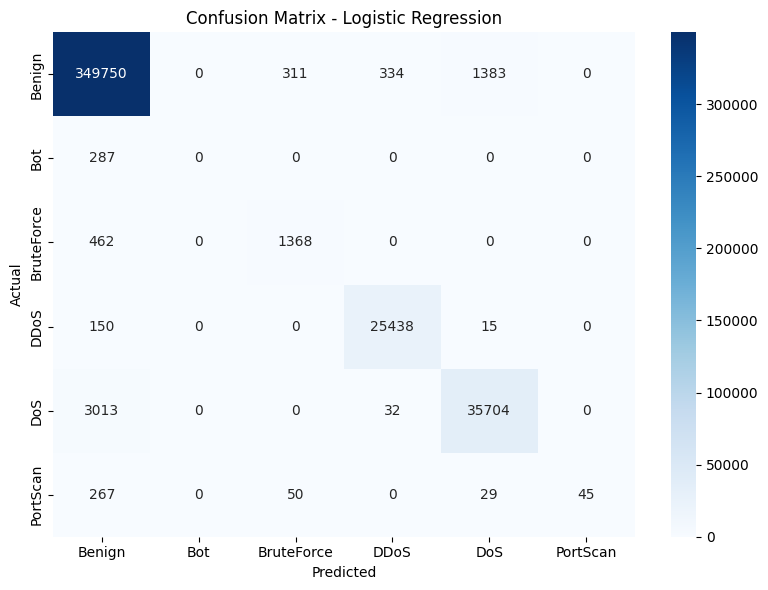

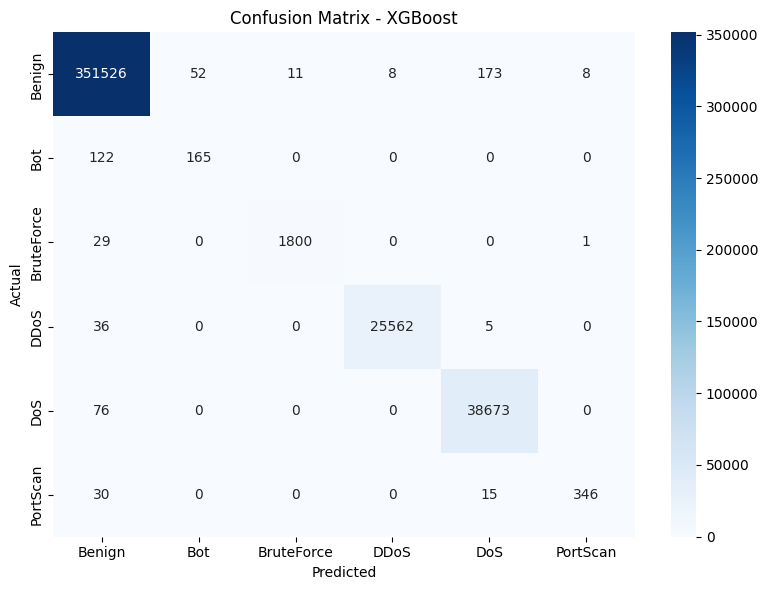

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create confusion matrices for all models
for name, pred in zip(model_names, fixed_preds):
    cm = confusion_matrix(y_test, pred, labels=np.unique(y_test))
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{name.replace(" ", "_")}.png', dpi=150)
    plt.show()

##  Step 12 — Feature Importance (Random Forest)

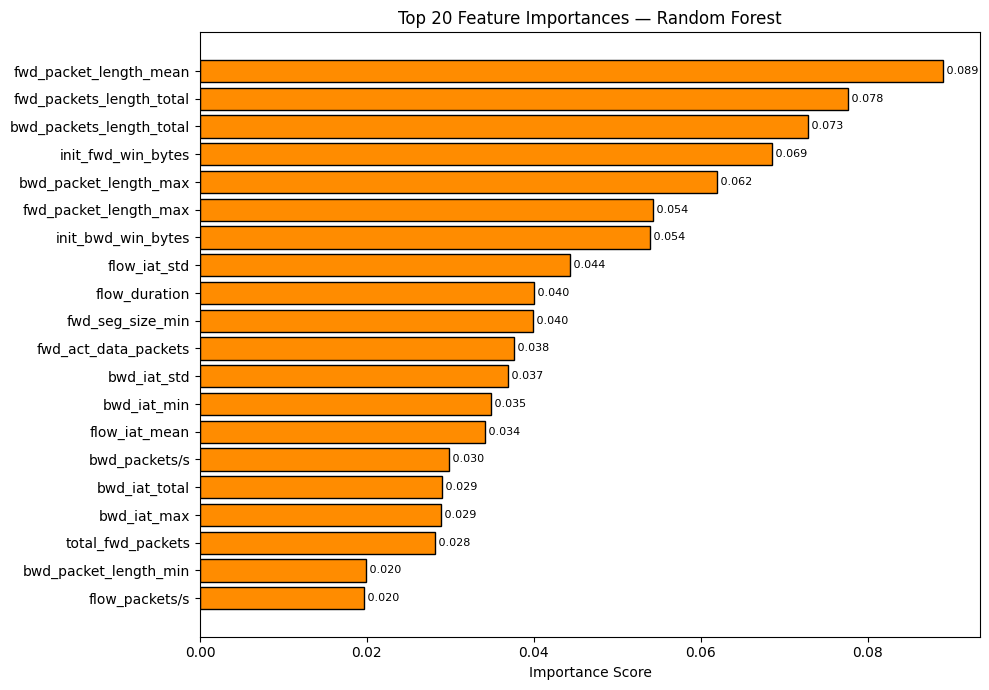

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

#  Safe feature importance extraction
feat_imp = pd.Series(
    model_rf.feature_importances_,
    index=X_train.columns   # safest (no mismatch issue)
).sort_values(ascending=False)

#  Plot Top 20 Features
plt.figure(figsize=(10, 7))
top_feat = feat_imp.head(20)

bars = plt.barh(top_feat.index, top_feat.values,
                color='darkorange', edgecolor='black')

plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances — Random Forest')
plt.xlabel('Importance Score')

#  Add values on bars (pro look)
for i, v in enumerate(top_feat.values):
    plt.text(v, i, f' {v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

##  Step 13 — Save Best Model

In [26]:
import joblib


model_objs = [model_rf, model_lr, model_xgb]

#  Find best model
best_idx   = accuracies.index(max(accuracies))
best_name  = model_names[best_idx]
best_model = model_objs[best_idx]

#  Save model
joblib.dump(best_model, 'final_model.pkl')

#  Save features
joblib.dump(X_train.columns.tolist(), 'selected_features.pkl')

#  Save scaler
joblib.dump(scaler, 'scaler.pkl')

#  Output
print(f'Best Model : {best_name}')
print(f' Accuracy   : {max(accuracies)*100:.2f}%')
print(' Saved: final_model.pkl')
print(' Saved: selected_features.pkl')
print(' Saved: scaler.pkl')

Best Model : Random Forest
 Accuracy   : 99.89%
 Saved: final_model.pkl
 Saved: selected_features.pkl
 Saved: scaler.pkl


# Step 14 — Predict on New Data

In [27]:
# Load saved objects
model_loaded    = joblib.load('final_model.pkl')
features_loaded = joblib.load('selected_features.pkl')
scaler_loaded   = joblib.load('scaler.pkl')


In [28]:
print(type(model_loaded))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [29]:
print(model_loaded)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)


In [30]:
print(features_loaded)
print(len(features_loaded))

['protocol', 'flow_duration', 'total_fwd_packets', 'fwd_packets_length_total', 'bwd_packets_length_total', 'fwd_packet_length_max', 'fwd_packet_length_mean', 'bwd_packet_length_max', 'bwd_packet_length_min', 'flow_bytes/s', 'flow_packets/s', 'flow_iat_mean', 'flow_iat_std', 'flow_iat_min', 'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean', 'bwd_iat_std', 'bwd_iat_max', 'bwd_iat_min', 'bwd_packets/s', 'fin_flag_count', 'down/up_ratio', 'init_fwd_win_bytes', 'init_bwd_win_bytes', 'fwd_act_data_packets', 'fwd_seg_size_min', 'active_mean', 'active_max', 'active_min']
30


In [31]:
print(scaler_loaded.mean_)
print(scaler_loaded.scale_)

[1.04027143e+01 1.89549780e+07 5.72131412e+00 5.43607188e+02
 3.96972229e+03 2.36919110e+02 6.62844023e+01 1.13213816e+03
 4.64816417e+01 2.38225891e+05 1.23236616e+04 1.50808913e+06
 3.68780612e+06 2.21699297e+04 1.05462512e+06 1.24504513e+07
 2.04494458e+06 1.87827739e+06 5.99112578e+06 9.64356765e+05
 2.74098072e+03 3.57002948e-02 6.80854939e-01 7.47190970e+03
 1.94907235e+03 2.79243045e+00 2.56765881e+01 7.87084216e+04
 1.56685340e+05 4.71596898e+04]
[5.38943077e+00 3.70042089e+07 8.36877176e+00 1.61711246e+03
 1.15935880e+04 5.70436064e+02 1.64161334e+02 2.14896171e+03
 6.43682792e+01 6.12678710e+05 5.60555424e+04 3.55792749e+06
 8.37171782e+06 1.12325111e+05 7.51073430e+06 3.16792898e+07
 7.81312249e+06 6.76400292e+06 1.91459766e+07 6.94565935e+06
 7.10958204e+03 1.85541865e-01 5.75158435e-01 1.50326985e+04
 7.57233110e+03 4.88898047e+00 6.33914569e+00 3.75526958e+05
 6.67040108e+05 2.60028125e+05]


In [ ]:
# Use unseen data (example: X_test)
new_data = pd.DataFrame(X_test, columns=features_loaded)

# Scale
new_data_scaled = scaler_loaded.transform(new_data)

# Predict
y_new_pred  = model_loaded.predict(new_data_scaled)
y_new_prob  = model_loaded.predict_proba(new_data_scaled)

confidence  = (np.max(y_new_prob, axis=1) * 100).round(2)

# Save results
result_df = new_data.copy()
result_df['predicted_label'] = y_new_pred
result_df['confidence_%']    = confidence

result_df.to_csv('predictions_output.csv', index=False)


In [41]:
import pandas as pd

pred_df = pd.read_csv('predictions_output.csv')

# Top 10 rows in a neat table
print(pred_df.head(10).to_string())

# print(pred_df[['predicted_label', 'confidence_%']].head(10).to_string())

   protocol  flow_duration  total_fwd_packets  fwd_packets_length_total  bwd_packets_length_total  fwd_packet_length_max  fwd_packet_length_mean  bwd_packet_length_max  bwd_packet_length_min   flow_bytes/s  flow_packets/s  flow_iat_mean  flow_iat_std  flow_iat_min  fwd_iat_min  bwd_iat_total  bwd_iat_mean  bwd_iat_std  bwd_iat_max  bwd_iat_min  bwd_packets/s  fin_flag_count  down/up_ratio  init_fwd_win_bytes  init_bwd_win_bytes  fwd_act_data_packets  fwd_seg_size_min    active_mean  active_max  active_min predicted_label  confidence_%
0        17        11918.0                  2                        64                     256.0                     32               32.000000                    128                    128   26850.142640      335.626783   3.972667e+03  6.836730e+03           3.0         3.00           48.0         48.00        0.000           48           48     167.813390               0              1                   0                   0                     1      

In [43]:

print(pred_df[['predicted_label', 'confidence_%']].head(30).to_string())

   predicted_label  confidence_%
0           Benign        100.00
1           Benign        100.00
2           Benign        100.00
3             DDoS        100.00
4           Benign        100.00
5           Benign        100.00
6           Benign        100.00
7           Benign        100.00
8              DoS        100.00
9           Benign         99.99
10          Benign        100.00
11          Benign        100.00
12          Benign        100.00
13          Benign        100.00
14          Benign        100.00
15             DoS        100.00
16      BruteForce        100.00
17            DDoS        100.00
18          Benign        100.00
19          Benign        100.00
20          Benign        100.00
21          Benign        100.00
22          Benign         98.31
23          Benign        100.00
24             DoS        100.00
25          Benign        100.00
26          Benign        100.00
27          Benign        100.00
28          Benign        100.00
29        

In [40]:
# Load features-only test data
X_new = pd.read_csv('test_dataset_without_label.csv')

# Load actual labels separately
y_true = pd.read_csv('test_dataset_with_label.csv')['label']  # adjust column name

# Load trained model and scaler
scaler = joblib.load('scaler.pkl')
model = joblib.load('final_model.pkl')

# Scale features
X_new_scaled = scaler.transform(X_new)

# Predict
y_pred = model.predict(X_new_scaled)

# Compare
simplified_df = pd.DataFrame({
    'Predicted Label': y_pred,
    'Actual Label': y_true,
    'Correct?': y_pred == y_true
})

# Overall accuracy
from sklearn.metrics import accuracy_score
overall_acc = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {overall_acc*100:.2f}%")

print(simplified_df.head(40))

Overall Accuracy: 99.89%
   Predicted Label Actual Label  Correct?
0           Benign       Benign      True
1           Benign       Benign      True
2           Benign       Benign      True
3             DDoS         DDoS      True
4           Benign       Benign      True
5           Benign       Benign      True
6           Benign       Benign      True
7           Benign       Benign      True
8              DoS          DoS      True
9           Benign       Benign      True
10          Benign       Benign      True
11          Benign       Benign      True
12          Benign       Benign      True
13          Benign       Benign      True
14          Benign       Benign      True
15             DoS          DoS      True
16      BruteForce   BruteForce      True
17            DDoS         DDoS      True
18          Benign       Benign      True
19          Benign       Benign      True
20          Benign       Benign      True
21          Benign       Benign      True
22       

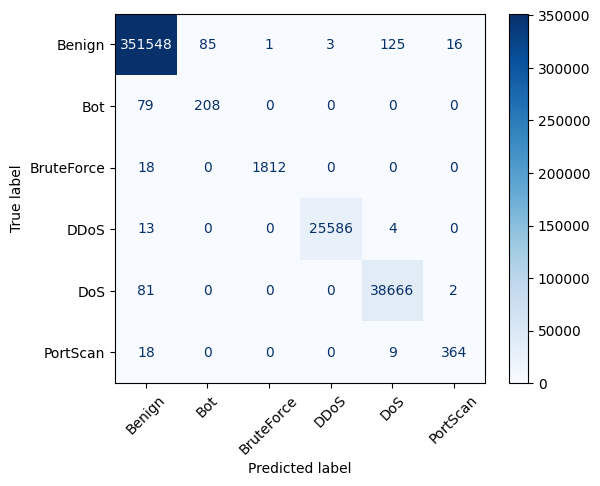

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    351778
         Bot       0.71      0.72      0.72       287
  BruteForce       1.00      0.99      0.99      1830
        DDoS       1.00      1.00      1.00     25603
         DoS       1.00      1.00      1.00     38749
    PortScan       0.95      0.93      0.94       391

    accuracy                           1.00    418638
   macro avg       0.94      0.94      0.94    418638
weighted avg       1.00      1.00      1.00    418638



In [43]:
per_class_acc = simplified_df.groupby('Actual Label')['Correct?'].mean() * 100
print(per_class_acc)

Actual Label
Benign        99.934618
Bot           72.473868
BruteForce    99.016393
DDoS          99.933602
DoS           99.785801
PortScan      93.094629
Name: Correct?, dtype: float64


In [44]:
import pandas as pd
from sklearn.metrics import accuracy_score

# simplified_df already has:
# 'Predicted Label', 'Actual Label', 'Correct?'

# Overall Accuracy
overall_acc = accuracy_score(simplified_df['Actual Label'], simplified_df['Predicted Label'])

# Total correct/incorrect
total_correct = simplified_df['Correct?'].sum()
total_incorrect = len(simplified_df) - total_correct

# Per-class accuracy
per_class_acc = simplified_df.groupby('Actual Label')['Correct?'].mean() * 100
per_class_count = simplified_df.groupby('Actual Label')['Correct?'].count()

# Combine into a summary DataFrame
summary_df = pd.DataFrame({
    'Total Rows': per_class_count,
    'Accuracy (%)': per_class_acc
}).reset_index().rename(columns={'index':'Class'})

# Add overall stats as a separate row
overall_row = pd.DataFrame([{
    'Class': 'Overall',
    'Total Rows': len(simplified_df),
    'Accuracy (%)': overall_acc*100
}])

summary_df = pd.concat([summary_df, overall_row], ignore_index=True)

# Save summary to CSV
summary_df.to_csv('prediction_summary.csv', index=False)
print("✅ Final prediction summary saved as 'prediction_summary.csv'")

✅ Final prediction summary saved as 'prediction_summary.csv'
